In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

from IPython.display import display, Latex


In [2]:
df = pd.read_csv("database-am-6.csv")
df = df.drop(columns=["Unnamed: 0"])

X = df.drop("Q092", axis=1)
y = df["Q092"]

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [3]:
def avaliar_modelo(modelo, X_treino, y_treino, X_teste, y_teste, nome="Modelo"):
    modelo.fit(X_treino, y_treino)
    y_pred = modelo.predict(X_teste)

    report_dict = classification_report(y_teste, y_pred, output_dict=True)
    df = pd.DataFrame(report_dict).transpose()
    df = df.round(2)
    df.rename(index={
    "0.0": "DN",
    "1.0": "DP"
    }, inplace=True)

    fig, ax = plt.subplots(figsize=(6, 2.5))
    ax.axis('off')
    tbl = ax.table(cellText=df.values, colLabels=df.columns, rowLabels=df.index, loc='center', cellLoc='center')
    tbl.scale(1.2, 1.5)
    plt.title(f"Resultados - {nome}", fontsize=12)
    plt.tight_layout()
    plt.show()


    cm = confusion_matrix(y_teste, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Matriz de Confusão - {nome}")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    
    if hasattr(modelo, "feature_importances_"):
        importancias = pd.Series(modelo.feature_importances_, index=X_treino.columns)
        top_importantes = importancias.sort_values(ascending=False).head(20)
        
        plt.figure(figsize=(8, 6))
        top_importantes.plot(kind="barh")
        plt.title(f"20 Variáveis Mais Relevantes - {nome}")
        plt.xlabel("Importância")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        
    return modelo, y_pred


In [4]:
def extrair_metricas(y_verdadeiro, y_predito, nome="Modelo"):
    report = classification_report(y_verdadeiro, y_predito, output_dict=True)
    return {
        "Modelo": nome,
        "Accuracy": accuracy_score(y_verdadeiro, y_predito),
        "0_Precision": report["0.0"]["precision"],
        "0_Recall": report["0.0"]["recall"],
        "0_F1": report["0.0"]["f1-score"],
        "1_Precision": report["1.0"]["precision"],
        "1_Recall": report["1.0"]["recall"],
        "1_F1": report["1.0"]["f1-score"],
        "F1_Macro": report["macro avg"]["f1-score"]
    }

## Treinamento com dados originais

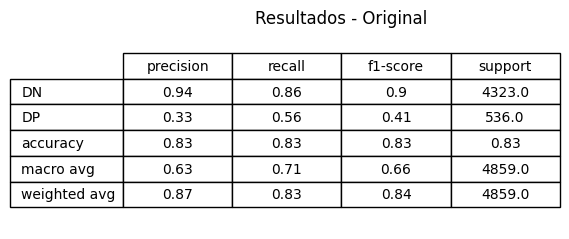

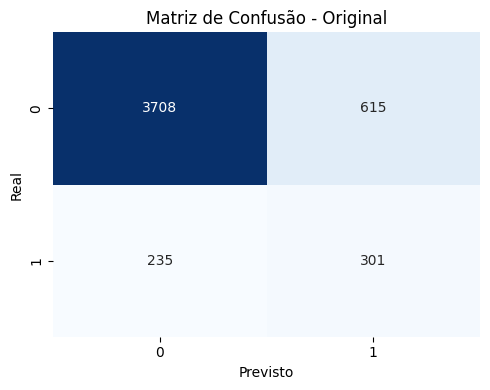

In [5]:
modelo_original = GaussianNB()
modelo_original, y_pred_original = avaliar_modelo(modelo_original, X_treino, y_treino, X_teste, y_teste, "Original")


## Balanceamento com under e over sampling

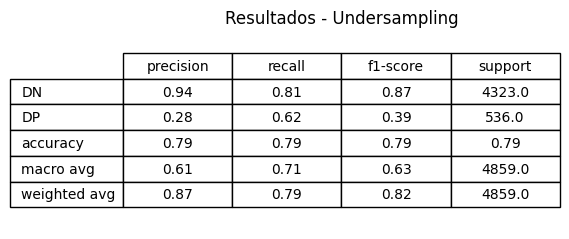

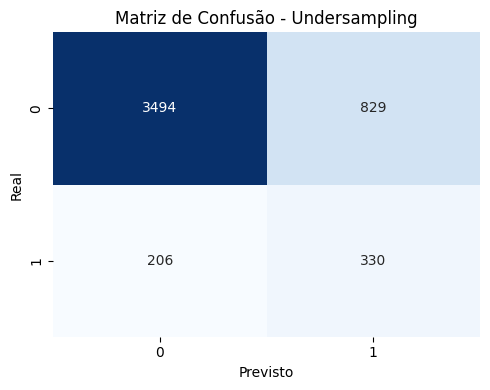

In [6]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_treino, y_treino)

modelo_under = GaussianNB()
modelo_under, y_pred_under = avaliar_modelo(modelo_under, X_rus, y_rus, X_teste, y_teste, "Undersampling")


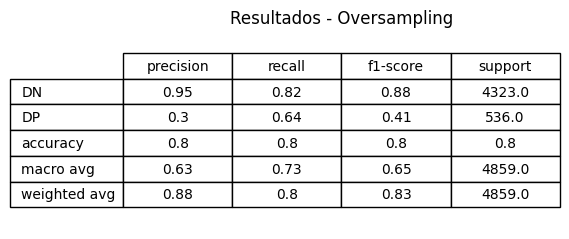

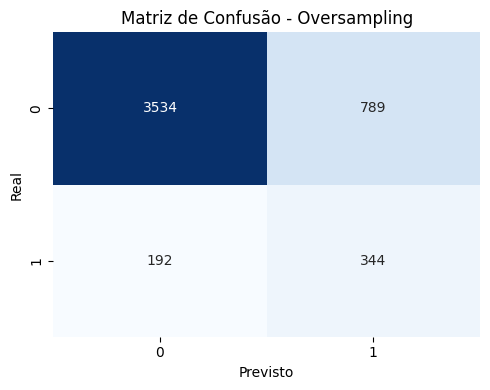

In [7]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_treino, y_treino)

modelo_over = GaussianNB()
modelo_over, y_pred_over = avaliar_modelo(modelo_over, X_smote, y_smote, X_teste, y_teste, "Oversampling")


## Comparação final

In [10]:

metricas = []

metricas.append(extrair_metricas(y_teste, modelo_original.predict(X_teste), "Original"))
metricas.append(extrair_metricas(y_teste, modelo_under.predict(X_teste), "Undersampling"))
metricas.append(extrair_metricas(y_teste, modelo_over.predict(X_teste), "Oversampling"))

df_resultados = pd.DataFrame(metricas).round(2)
display(df_resultados)
df_resultados.to_latex("tabela_comparativa_modelos.tex", index=False, float_format="%.2f")

,Modelo,Accuracy,0_Precision,0_Recall,0_F1,1_Precision,1_Recall,1_F1,F1_Macro
0,Original,0.83,0.94,0.86,0.90,0.33,0.56,0.41,0.66
1,Undersampling,0.79,0.94,0.81,0.87,0.28,0.62,0.39,0.63
2,Oversampling,0.80,0.95,0.82,0.88,0.30,0.64,0.41,0.65
